# Pinky-Pro QR / ArUco 검출 테스트

Pinky-Pro 카메라 영상에서 QR 데이터와 ArUco 마커를 검출하기 위한 노트북입니다.

In [1]:
import cv2
import numpy as np

if not hasattr(cv2, 'aruco'):
    raise ImportError('OpenCV ArUco 모듈이 필요합니다: pip install opencv-contrib-python')


def make_aruco_detector(dictionary_id):
    dictionary = cv2.aruco.getPredefinedDictionary(dictionary_id)
    if hasattr(cv2.aruco, 'ArucoDetector'):
        parameters = cv2.aruco.DetectorParameters()
        detector = cv2.aruco.ArucoDetector(dictionary, parameters)
        return detector.detectMarkers
    parameters = cv2.aruco.DetectorParameters_create()
    return lambda image: cv2.aruco.detectMarkers(
        image, dictionary, parameters=parameters
    )


def _polygon_points(points):
    return np.asarray(points, dtype=np.float32).reshape(-1, 2)


def detect_qr_codes(frame):
    annotated = frame.copy()
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    enhanced = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8)).apply(gray)
    blurred = cv2.GaussianBlur(enhanced, (0, 0), 1.2)
    sharpened = cv2.addWeighted(enhanced, 1.8, blurred, -0.8, 0)
    scale = 2.0
    results = []
    seen = []

    for candidate in (gray, enhanced, sharpened):
        enlarged = cv2.resize(
            candidate, None, fx=scale, fy=scale, interpolation=cv2.INTER_CUBIC
        )
        detector = cv2.QRCodeDetector()
        candidates = []
        try:
            found, decoded_info, points, _ = detector.detectAndDecodeMulti(enlarged)
            if found and points is not None:
                candidates.extend(zip(decoded_info, points))
        except (AttributeError, cv2.error):
            pass

        if not candidates:
            data, points, _ = detector.detectAndDecode(enlarged)
            if data and points is not None:
                candidates.append((data, points))

        for data, points in candidates:
            if not data:
                continue
            polygon = _polygon_points(points) / scale
            if len(polygon) != 4:
                continue
            center = polygon.mean(axis=0)
            if any(
                old_data == data and np.linalg.norm(center - old_center) < 10.0
                for old_data, old_center in seen
            ):
                continue
            seen.append((data, center))
            results.append({'data': data, 'corners': polygon.tolist()})

    for result in results:
        integer_polygon = np.round(result['corners']).astype(np.int32)
        cv2.polylines(annotated, [integer_polygon], True, (0, 255, 0), 3)
        x, y = integer_polygon[0]
        cv2.putText(
            annotated, f"QR: {result['data']}",
            (int(x), max(25, int(y) - 10)),
            cv2.FONT_HERSHEY_SIMPLEX, 0.65, (0, 255, 0), 2
        )
    return annotated, results


def stabilize_qr_results(current, previous, miss_count, miss_limit=5):
    if current:
        return current, 0
    next_miss_count = miss_count + 1
    if previous and next_miss_count < miss_limit:
        return previous, next_miss_count
    return [], next_miss_count


def draw_held_qr_results(frame, results):
    annotated = frame.copy()
    for result in results:
        polygon = np.round(np.asarray(result['corners'])).astype(np.int32)
        cv2.polylines(annotated, [polygon], True, (0, 200, 255), 2)
        x, y = polygon[0]
        cv2.putText(
            annotated, f"QR(hold): {result['data']}",
            (int(x), max(25, int(y) - 10)),
            cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 200, 255), 2
        )
    return annotated


def _estimate_square_pose(corners, marker_size_m, camera_matrix, dist_coeffs):
    half = marker_size_m / 2.0
    object_points = np.array(
        [[-half, half, 0.0], [half, half, 0.0],
         [half, -half, 0.0], [-half, -half, 0.0]],
        dtype=np.float32,
    )
    success, rvec, tvec = cv2.solvePnP(
        object_points, corners.astype(np.float32), camera_matrix, dist_coeffs,
        flags=cv2.SOLVEPNP_IPPE_SQUARE,
    )
    if not success:
        return None, None
    return rvec.reshape(3), tvec.reshape(3)


def detect_aruco_markers(
    frame, dictionary_specs, camera_matrix=None, dist_coeffs=None
):
    annotated = frame.copy()
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    results = []
    seen_centers = []

    for dictionary_name, dictionary_id, marker_size_m in dictionary_specs:
        corners_list, ids, _ = make_aruco_detector(dictionary_id)(gray)
        if ids is None:
            continue
        for marker_corners, marker_id in zip(corners_list, ids.flatten()):
            corners = _polygon_points(marker_corners)
            center = corners.mean(axis=0)
            if any(np.linalg.norm(center - old) < 5.0 for old in seen_centers):
                continue
            seen_centers.append(center)
            rvec = tvec = None
            if camera_matrix is not None and dist_coeffs is not None:
                rvec, tvec = _estimate_square_pose(
                    corners, marker_size_m, camera_matrix, dist_coeffs
                )
            polygon = np.round(corners).astype(np.int32)
            cv2.polylines(annotated, [polygon], True, (255, 0, 0), 2)
            label = f'{dictionary_name} ID={int(marker_id)}'
            if tvec is not None:
                label += f' xyz=({tvec[0]:.3f}, {tvec[1]:.3f}, {tvec[2]:.3f})m'
                cv2.drawFrameAxes(
                    annotated, camera_matrix, dist_coeffs,
                    rvec.reshape(3, 1), tvec.reshape(3, 1), marker_size_m * 0.5
                )
            x, y = polygon[0]
            cv2.putText(
                annotated, label, (int(x), max(20, int(y) - 10)),
                cv2.FONT_HERSHEY_SIMPLEX, 0.45, (255, 0, 0), 2
            )
            results.append({
                'dictionary': dictionary_name,
                'id': int(marker_id),
                'corners': corners.tolist(),
                'rvec': None if rvec is None else rvec.tolist(),
                'tvec_m': None if tvec is None else tvec.tolist(),
            })
    return annotated, results


## 실행 순서와 준비물

1. `pinkylib`, `opencv-contrib-python`, `numpy`가 설치된 Pinky-Pro Jupyter 환경에서 실행합니다.
2. 내부 코너가 **8×6**, 한 칸이 **25 mm**인 체커보드를 준비합니다.
3. `2. 체커보드 촬영` 셀에서 각도와 거리를 바꾸며 선명한 사진을 15~25장 저장합니다.
4. `3. 캘리브레이션` 셀로 `camera_calibration.npz`를 생성합니다.
5. `4. 실시간 QR + ArUco 테스트` 셀을 실행하고 셀 중지 버튼 또는 `Kernel → Interrupt`로 종료합니다.

> `MARKER_SIZE_M`는 흰 여백을 제외한 바깥쪽 검은 정사각형의 실제 한 변입니다. 현재 값은 30 mm입니다.

## 1. 환경 및 설정

In [2]:
from pathlib import Path
import time

from pinkylib import Camera

CHECKERBOARD = (8, 6)      # 체커보드 내부 코너 수 (가로, 세로)
SQUARE_SIZE_M = 0.025      # 체커보드 한 칸: 25 mm
MARKER_SIZE_M = 0.03       # 검은 마커 영역 한 변: 30 mm
CALIB_DIR = Path('./pinky_test/calib_img')
CALIBRATION_FILE = Path('camera_calibration.npz')
CALIB_DIR.mkdir(parents=True, exist_ok=True)

# 전체가 7×7칸으로 보이는 마커 = 내부 데이터 5×5 + 테두리입니다.
ARUCO_DICTIONARIES = [
    ('DICT_5X5_100', cv2.aruco.DICT_5X5_100, MARKER_SIZE_M),
]
# 4×4 마커라면 위 목록을 아래처럼 바꾸세요.
# ARUCO_DICTIONARIES = [('DICT_4X4_100', cv2.aruco.DICT_4X4_100, MARKER_SIZE_M)]

print('OpenCV:', cv2.__version__)
print('Checkerboard:', CHECKERBOARD, '/', SQUARE_SIZE_M, 'm')
print('ArUco:', ARUCO_DICTIONARIES)
print('Save Path:', CALIB_DIR)


OpenCV: 4.10.0
Checkerboard: (8, 6) / 0.025 m
ArUco: [('DICT_5X5_100', 5, 0.03)]
Save Path: pinky_test/calib_img


## 2. 체커보드 촬영

- `c`: 현재 프레임의 코너를 검사하고, 8×6 코너가 모두 검출되면 저장
- `q`: 촬영 종료

체커보드가 화면의 중앙·모서리·가까운 곳·먼 곳에 나타나도록 위치와 기울기를 바꿔 주세요. 흐리거나 반사가 심한 사진은 저장하지 마세요.

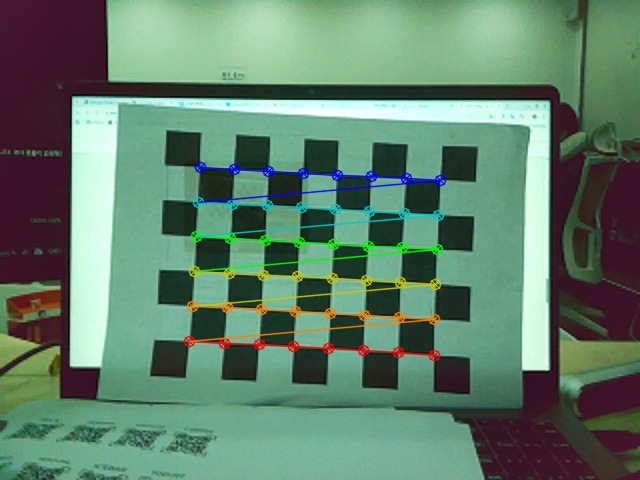

저장: pinky_test/calib_img/015.jpg


c=촬영, q=종료:  q


카메라를 닫았습니다.


In [3]:
cam = Camera()
try:
    cam.start()
    existing = [int(path.stem) for path in CALIB_DIR.glob('*.jpg') if path.stem.isdigit()]
    file_number = max(existing, default=0) + 1
    print(f'저장 폴더: {CALIB_DIR.resolve()} / 다음 번호: {file_number}')

    while True:
        command = input('c=촬영, q=종료: ').strip().lower()
        if command == 'q':
            break
        if command != 'c':
            print('c 또는 q를 입력하세요.')
            continue

        frame = cam.get_frame()
        if frame is None:
            print('카메라 프레임을 읽지 못했습니다.')
            continue
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        if hasattr(cv2, 'findChessboardCornersSB'):
            found, corners = cv2.findChessboardCornersSB(gray, CHECKERBOARD)
        else:
            found, corners = cv2.findChessboardCorners(gray, CHECKERBOARD)

        preview = frame.copy()
        cv2.drawChessboardCorners(preview, CHECKERBOARD, corners, found)
        cam.display_jupyter(preview)
        if not found:
            print('8×6 내부 코너를 모두 찾지 못했습니다. 자세를 바꿔 다시 촬영하세요.')
            continue

        output_path = CALIB_DIR / f'{file_number:03d}.jpg'
        if not cv2.imwrite(str(output_path), frame):
            raise OSError(f'이미지를 저장하지 못했습니다: {output_path}')
        print(f'저장: {output_path}')
        file_number += 1
finally:
    cam.close()
    print('카메라를 닫았습니다.')


## 3. 캘리브레이션

최소 10장, 권장 15~25장의 유효 사진으로 카메라 행렬과 왜곡 계수를 계산합니다. RMS 값이 작을수록 재투영 오차가 작습니다. 값이 크거나 실제 거리 오차가 크면 다양한 각도의 선명한 사진으로 다시 촬영하세요.

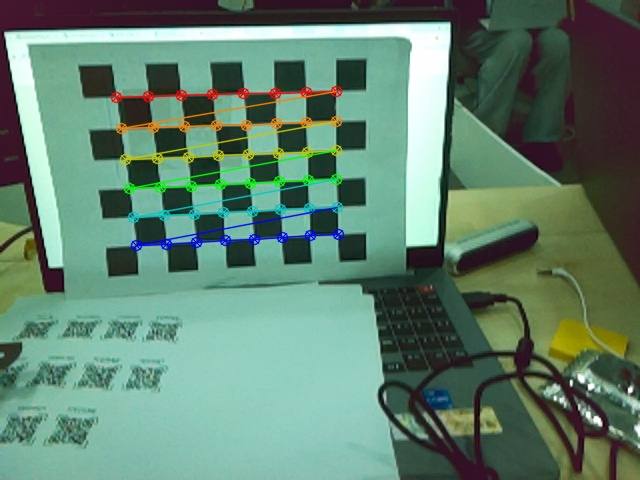

pinkylib 캘리브레이션 생성/적용 완료


In [4]:
image_paths = sorted(CALIB_DIR.glob('*.jpg'))
if not image_paths:
    raise RuntimeError(f'캘리브레이션 이미지가 없습니다: {CALIB_DIR.resolve()}')

object_template = np.zeros((CHECKERBOARD[0] * CHECKERBOARD[1], 3), np.float32)
object_template[:, :2] = np.mgrid[0:CHECKERBOARD[0], 0:CHECKERBOARD[1]].T.reshape(-1, 2)
object_template *= SQUARE_SIZE_M
object_points = []
image_points = []
image_size = None
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001)

for image_path in image_paths:
    image = cv2.imread(str(image_path))
    if image is None:
        print('읽기 실패, 제외:', image_path)
        continue
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    image_size = gray.shape[::-1]
    found, corners = cv2.findChessboardCorners(gray, CHECKERBOARD)
    if not found:
        print('코너 검출 실패, 제외:', image_path.name)
        continue
    refined = cv2.cornerSubPix(gray, corners, (11, 11), (-1, -1), criteria)
    object_points.append(object_template.copy())
    image_points.append(refined)

if len(object_points) < 10:
    raise RuntimeError(f'유효 이미지가 {len(object_points)}장뿐입니다. 최소 10장을 촬영하세요.')

rms, camera_matrix, dist_coeffs, rvecs, tvecs = cv2.calibrateCamera(
    object_points, image_points, image_size, None, None
)
np.savez(
    CALIBRATION_FILE, camera_matrix=camera_matrix,
    dist_coeffs=dist_coeffs, rms=np.array(rms)
)
print(f'유효 이미지: {len(object_points)} / RMS: {rms:.6f}')
print('camera_matrix:\n', camera_matrix)
print('dist_coeffs:', dist_coeffs.ravel())
print('OpenCV 보정값 저장:', CALIBRATION_FILE.resolve())

# Pinky-Pro 라이브러리 보정 파일도 생성하고 적용합니다.
pinky_calibration_cam = Camera()
try:
    pinky_calibration_cam.calibration_camera(str(CALIB_DIR))
    pinky_calibration_cam.set_calibration()
    print('pinkylib 캘리브레이션 생성/적용 완료')
except Exception as exc:
    print('pinkylib 캘리브레이션 호출 실패:', exc)
    print('OpenCV camera_calibration.npz는 생성되었습니다. pinkylib 버전/API를 확인하세요.')
finally:
    pinky_calibration_cam.close()


## 재투영 오차 확인
- < 0.5 px: 양호
- 0.5~1.0 px: 보통, 대체로 사용 가능

In [6]:
total_error = 0.0
per_image_errors = []

for i in range(len(object_points)):
    projected, _ = cv2.projectPoints(
        object_points[i],
        rvecs[i],
        tvecs[i],
        camera_matrix,
        dist_coeffs,
    )

    error = cv2.norm(
        image_points[i],
        projected,
        cv2.NORM_L2,
    ) / len(projected)

    per_image_errors.append(error)
    total_error += error

mean_error = total_error / len(object_points)

print("평균 재투영 오차:", mean_error, "px")
for index, error in enumerate(per_image_errors):
    print(f"{index + 1:02d}: {error:.4f} px")

평균 재투영 오차: 0.07740247142123871 px
01: 0.0843 px
02: 0.0525 px
03: 0.0777 px
04: 0.0902 px
05: 0.0622 px
06: 0.0681 px
07: 0.1434 px
08: 0.0532 px
09: 0.1041 px
10: 0.1025 px
11: 0.0468 px
12: 0.0603 px
13: 0.0630 px
14: 0.0903 px
15: 0.0623 px
The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


## 왜곡 보정 결과를 눈으로 확인

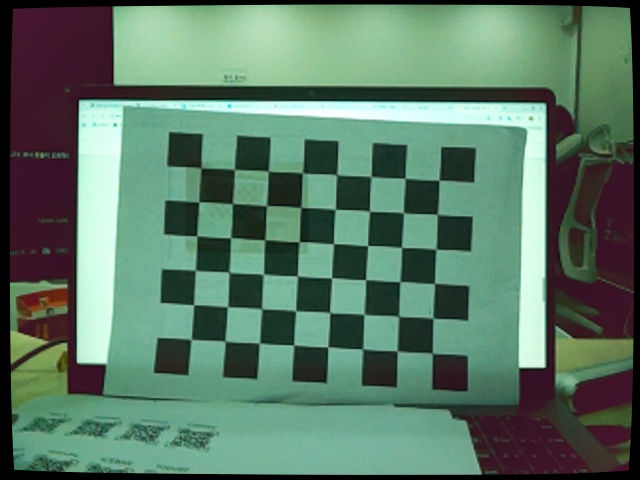

In [7]:
undistorted = cv2.undistort(
    frame,
    camera_matrix,
    dist_coeffs,
)

cam.display_jupyter(undistorted)

## 4. 실시간 QR + ArUco 테스트

QR은 초록색, ArUco는 파란색 테두리와 좌표축으로 표시됩니다. ArUco 출력의 `x/y/z` 단위는 m입니다. 카메라 기준으로 일반적으로 `x`는 좌우, `y`는 상하, `z`는 카메라 앞쪽 거리입니다.

셀 중지 버튼 또는 `Kernel → Interrupt`로 종료하세요.

In [9]:
from pathlib import Path
import numpy as np

print("파일 경로:", CALIBRATION_FILE.resolve())
print("파일 존재:", CALIBRATION_FILE.exists())

with np.load(CALIBRATION_FILE) as calibration:
    print("저장된 키:", calibration.files)
    for key in calibration.files:
        print(key, calibration[key].shape)

파일 경로: /home/pinky/pinky_test/camera_calibration.npz
파일 존재: True
저장된 키: ['camera_matrix', 'distortion_coefficients', 'rvecs', 'tvecs']
camera_matrix (3, 3)
distortion_coefficients (1, 5)
rvecs (15, 3, 1)
tvecs (15, 3, 1)


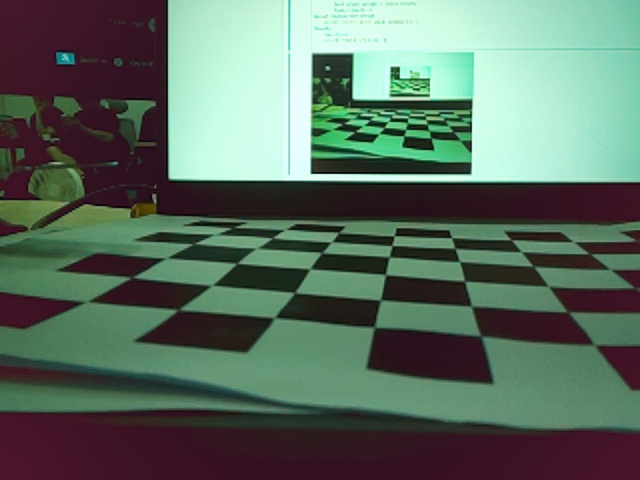

사용자가 실시간 검출을 중지했습니다.
카메라를 닫았습니다.


In [11]:
if not CALIBRATION_FILE.exists():
    raise FileNotFoundError('먼저 3. 캘리브레이션 셀을 실행하세요.')

with np.load(CALIBRATION_FILE) as calibration:
    print("저장된 키:", calibration.files)

    camera_matrix = calibration["camera_matrix"]

    if "dist_coeffs" in calibration.files:
        dist_coeffs = calibration["dist_coeffs"]
    elif "distortion_coefficients" in calibration.files:
        dist_coeffs = calibration["distortion_coefficients"]
    else:
        raise KeyError("캘리브레이션 파일에 왜곡 계수가 없습니다.")

    calibration_rms = (
        float(calibration["rms"])
        if "rms" in calibration.files
        else None
    )

if calibration_rms is None:
    print("캘리브레이션 로드 완료 (RMS 정보 없음)")
else:
    print(f"캘리브레이션 로드 완료 (RMS={calibration_rms:.6f})")

cam = Camera()
last_qr_values = None
stable_qr_results = []
qr_miss_count = 0
QR_MISS_LIMIT = 5
last_aruco_values = None
frame_shape_printed = False
try:
    cam.set_calibration()
    cam.start()
    while True:
        frame = cam.get_frame()
        if frame is None:
            print('카메라 프레임을 읽지 못했습니다.')
            time.sleep(0.1)
            continue

        if not frame_shape_printed:
            height, width = frame.shape[:2]
            print(f'카메라 원본 해상도: {width}x{height}')
            frame_shape_printed = True

        annotated, qr_results = detect_qr_codes(frame)
        annotated, aruco_results = detect_aruco_markers(
            annotated, ARUCO_DICTIONARIES, camera_matrix, dist_coeffs
        )
        stable_qr_results, qr_miss_count = stabilize_qr_results(
            qr_results, stable_qr_results, qr_miss_count, QR_MISS_LIMIT
        )
        if not qr_results and stable_qr_results:
            annotated = draw_held_qr_results(annotated, stable_qr_results)
        cam.display_jupyter(annotated)

        qr_values = tuple(item['data'] for item in stable_qr_results)
        if qr_values and qr_values != last_qr_values:
            for value in qr_values:
                print('QR:', value)
        last_qr_values = qr_values or None

        aruco_values = tuple(
            (item['dictionary'], item['id'], *(round(v, 4) for v in item['tvec_m']))
            for item in aruco_results if item['tvec_m'] is not None
        )
        if aruco_values and aruco_values != last_aruco_values:
            for dictionary_name, marker_id, x, y, z in aruco_values:
                print(f'ArUco {dictionary_name} ID={marker_id}: x={x:.4f}m y={y:.4f}m z={z:.4f}m')
        last_aruco_values = aruco_values
        time.sleep(0.1)
except KeyboardInterrupt:
    print('사용자가 실시간 검출을 중지했습니다.')
finally:
    cam.close()
    print('카메라를 닫았습니다.')


## 5. 비상 카메라 정리

앞 셀이 강제 중단되어 카메라가 잡혀 있다고 의심될 때만 실행하세요.

In [12]:
if 'cam' in globals():
    try:
        cam.close()
    except Exception as exc:
        print('카메라 정리 중 오류:', exc)
print('카메라 정리 요청 완료')


카메라 정리 요청 완료
